In [1]:
import shutil
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from pathlib import Path
from sklearn.metrics import ConfusionMatrixDisplay

from python import classes, metrics, data_loader

In [2]:
notebook_classification = ""
notebook_cv = 0

image_size = 64
batch_size = 64
max_epochs = 300
lr_scheduler_patience = 10
early_stopping_patience = 15
total_cv = 5

data_dir = "data"
tensorboard_dir = "out/logs"
metrics_dir = "out/metrics"
models_dir = "out/keras"
weights_dir = "out/weights"

In [3]:
# Parameters
notebook_classification = "types"
notebook_cv = 2


In [4]:
assert notebook_classification in ['models', 'types'], "notebook_classification must be one of ['models', 'types']"
assert notebook_cv != 0, "notebook_cv must be provided"
assert 1 <= notebook_cv <= total_cv, "notebook_cv must be in the range [1, total_cv]"

In [5]:
class_names = classes.class_names[notebook_classification]
classes_num = len(class_names)

notebook_model = "m1"
data_dir = Path(data_dir) / f"{notebook_classification}"
tensorboard_dir = Path(tensorboard_dir) / f"{notebook_model}/{notebook_classification}/cv{notebook_cv}"
metrics_file = Path(metrics_dir) / f"{notebook_model}/{notebook_classification}.json"
model_file = Path(models_dir) / f"{notebook_model}/{notebook_classification}/cv{notebook_cv}.keras"
weights_file = Path(weights_dir) / f"{notebook_model}/{notebook_classification}/cv{notebook_cv}.weights.h5"

In [6]:
assert not model_file.is_file(), "This model already exists"

In [7]:
shutil.rmtree(tensorboard_dir, ignore_errors=True)

tensorboard_dir.mkdir(parents=True, exist_ok=True)
metrics_file.parent.mkdir(parents=True, exist_ok=True)
model_file.parent.mkdir(parents=True, exist_ok=True)
weights_file.parent.mkdir(parents=True, exist_ok=True)

In [8]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [9]:
train_data, val_data = data_loader.load_data(
    data_dir=data_dir,
    val_fold=notebook_cv,
    total_folds=total_cv,
    class_names=class_names,
    batch_size=batch_size,
    image_size=image_size
)

Found 6384 files belonging to 2 classes.


Found 6384 files belonging to 2 classes.
Found 6383 files belonging to 2 classes.


Found 6383 files belonging to 2 classes.
Found 6383 files belonging to 2 classes.


In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1)
])

In [11]:
model = models.Sequential()

# Input layer
model.add(layers.Input(shape=(image_size, image_size, 3)))
model.add(data_augmentation)
model.add(layers.Rescaling(1./255))

# First block
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.2))

# Second block
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.2))

# Third block
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.2))

# Fully connected layers
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

# Output layer
model.add(layers.Dense(classes_num, activation='softmax'))

model.summary()

Model: "sequential_1"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 sequential (Sequential)     (None, 64, 64, 3)         0         


 rescaling (Rescaling)       (None, 64, 64, 3)         0         


...

 dense_1 (Dense)             (None, 2)                 258       


Total params: 1,163,074


Trainable params: 1,162,306


Non-trainable params: 768


_________________________________________________________________


In [12]:
model.compile(
    optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        'accuracy', 
        metrics.F1Macro(classes_num), 
        metrics.PrecisionMacro(classes_num),
        metrics.RecallMacro(classes_num)
    ]
)

In [13]:
tensorboard = TensorBoard(log_dir=tensorboard_dir)
checkpoint = ModelCheckpoint(weights_file, save_best_only=True, save_weights_only=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', patience=lr_scheduler_patience, min_lr=1e-6)
early_stopping = EarlyStopping(monitor='val_loss', patience=early_stopping_patience)

model.fit(
    train_data, epochs=max_epochs, validation_data=val_data, verbose=2,
    callbacks=[
        tensorboard, checkpoint, lr_scheduler, early_stopping
    ]
);

Epoch 1/300


400/400 - 30s - loss: 0.3412 - accuracy: 0.8800 - f1: 0.5225 - precision: 0.5249 - recall: 0.5210 - val_loss: 2.6394 - val_accuracy: 0.6190 - val_f1: 0.4572 - val_precision: 0.5181 - val_recall: 0.5628 - lr: 0.0010 - 30s/epoch - 75ms/step


Epoch 2/300


400/400 - 27s - loss: 0.2475 - accuracy: 0.9247 - f1: 0.5547 - precision: 0.6854 - recall: 0.5402 - val_loss: 1.0230 - val_accuracy: 0.7188 - val_f1: 0.5367 - val_precision: 0.5569 - val_recall: 0.6755 - lr: 0.0010 - 27s/epoch - 67ms/step


Epoch 3/300


...

400/400 - 24s - loss: 0.0823 - accuracy: 0.9726 - f1: 0.8884 - precision: 0.9373 - recall: 0.8507 - val_loss: 0.0807 - val_accuracy: 0.9756 - val_f1: 0.9006 - val_precision: 0.9504 - val_recall: 0.8622 - lr: 1.0000e-05 - 24s/epoch - 61ms/step


Epoch 61/300


400/400 - 24s - loss: 0.0825 - accuracy: 0.9714 - f1: 0.8826 - precision: 0.9350 - recall: 0.8430 - val_loss: 0.0806 - val_accuracy: 0.9756 - val_f1: 0.9006 - val_precision: 0.9504 - val_recall: 0.8622 - lr: 1.0000e-05 - 24s/epoch - 60ms/step


Epoch 62/300


400/400 - 25s - loss: 0.0810 - accuracy: 0.9731 - f1: 0.8903 - precision: 0.9410 - recall: 0.8515 - val_loss: 0.0806 - val_accuracy: 0.9759 - val_f1: 0.9017 - val_precision: 0.9529 - val_recall: 0.8623 - lr: 1.0000e-05 - 25s/epoch - 63ms/step


In [14]:
model.load_weights(weights_file)
model.save(model_file)

In [15]:
fold_metrics = metrics.evaluate_metrics(model, val_data)
metrics.save_metrics(fold_metrics, metrics_file, notebook_cv)
fold_metrics

{'f1': 0.8997727632522583,
 'precision': 0.9468490481376648,
 'recall': 0.8629666566848755}

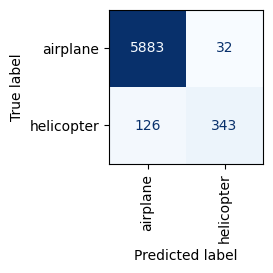

In [16]:
y_true, y_pred = metrics.model_predict(model, val_data)

fig, ax = plt.subplots(figsize=(classes_num, classes_num))
cmp = ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, 
    display_labels=class_names, 
    cmap=plt.get_cmap('Blues'),
    colorbar=False, 
    xticks_rotation='vertical', 
    ax=ax
)